# Clustering Analysis

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

In [74]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime

In [75]:
tracks_df = pd.read_csv("../datasets/tracks_prepared.csv")
artists_df = pd.read_csv("../datasets/artists_prepared.csv")

### Select which features will be used

In [76]:
# Print all feature names
tracks_original_features = tracks_df.columns.tolist()
print(tracks_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(tracks_original_features)}")

['id_artist', 'name_artist', 'title', 'featured_artists', 'language', 'stats_pageviews', 'swear_IT', 'swear_EN', 'swear_IT_words', 'swear_EN_words', 'year', 'month', 'day', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_name', 'album_release_date', 'album_type', 'track_number', 'duration_ms', 'explicit', 'popularity', 'outlier', 'outlier_score', 'arrapante', 'arrapare', 'arrapato', 'bagascia', 'bastardi', 'bastardo', 'battona', 'bernarda', 'bischero', 'blowjob', 'bocchinaro', 'bocchino', 'bombare', 'cacare', 'cacata', 'cacca', 'cagare', 'cagata', 'cagna', 'cappella', 'cazzata', 'cazzeggiare', 'cazzeggio', 'cazzi', 'cazzo', 'cazzone', 'cazzuto', 'cesso', 'checca', 'chiappa', 'chiavare', 'chiavata', 'cogliona', 'coglionata', 'coglione', 'coglioni', 'controcazzi', 'controcoglioni', 'cornuto', 'cozza', 'cretina', 'cretini', 'cretino', 'culattone', 

In [77]:
# Print all feature names
artists_original_features = artists_df.columns.tolist()
print(artists_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(artists_original_features)}")

['id_author', 'name', 'gender', 'birth_date', 'birth_place', 'nationality', 'description', 'active_start', 'active_end', 'province', 'region', 'country', 'latitude', 'longitude', 'starting_age', 'artist_age', 'birth_year', 'artist_collab_rate']

Total number of features: 18


## Features Selection

In [78]:
selected_features = [
    # linguistic / lyrics
    'n_tokens',
    # 'tokens_per_sent', 'char_per_tok', 'lexical_density',
    # 'avg_token_per_clause',

    # audio features
    # 'bpm', 'centroid', 'rolloff', 'flux',
    # 'spectral_complexity', 'pitch', 'loudness',

    # popularity
    'popularity', 'relative_popularity',

    # time-related
    'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    'has_collaboration', 'swear_ratio', 'aggressiveness'
]

In [79]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [80]:
# Check for remaining NaNs
print(X.isna().sum())


n_tokens               0
popularity             0
relative_popularity    0
season_autumn          0
season_spring          0
season_summer          0
season_winter          0
has_collaboration      0
swear_ratio            0
aggressiveness         0
dtype: int64


Skewness of continuous features:
 popularity             15.181913
swear_ratio             5.044610
n_tokens                1.173797
relative_popularity     0.265483
aggressiveness          0.082765
dtype: float64


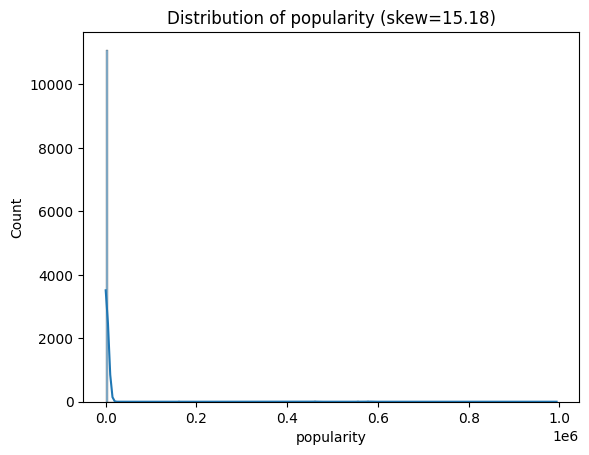

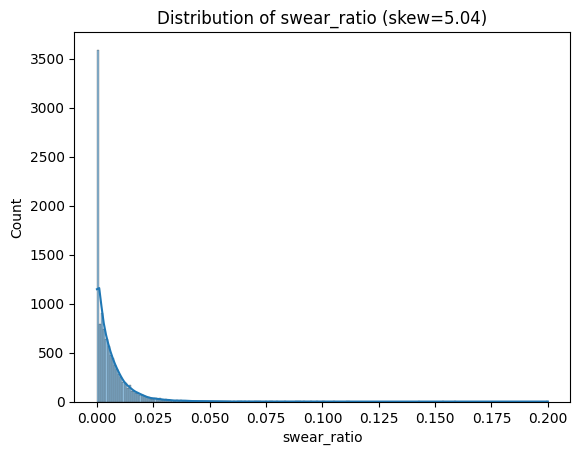

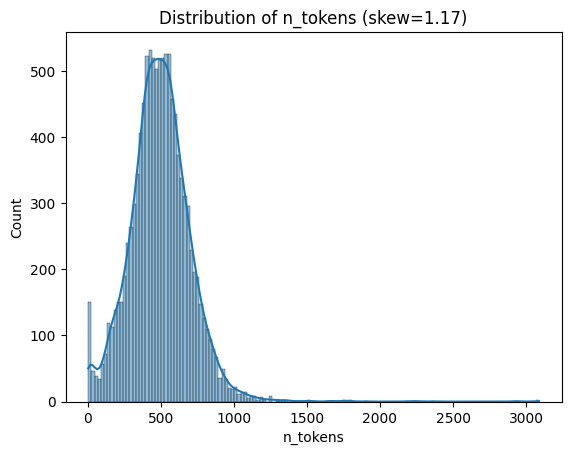

Skewness after log1p transformation:
 swear_ratio            4.678938
popularity             2.883568
relative_popularity    0.265483
aggressiveness         0.082765
n_tokens              -3.454655
dtype: float64


In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for clustering
numeric_features = X.columns.tolist()  # X is your selected features for clustering

# Step 0: Filter out binary / one-hot encoded features (only keep features with >2 unique values)
continuous_features = [col for col in numeric_features if X[col].nunique() > 2]

# Step 1: Compute skewness
skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n", skewness)

# Step 2: Plot distribution of highly skewed features (optional)
high_skew = skewness[skewness > 1].index  # threshold for positive skew
for col in high_skew:
    plt.figure()
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col} (skew={skewness[col]:.2f})')
    plt.show()

# Step 3: Apply log1p transformation to highly skewed continuous features
for col in high_skew:
    # Only apply if all values are >= 0 (log1p cannot handle negative values)
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])
    else:
        print(f"Skipping {col} because it has negative values.")

# Step 4: Verify the new skewness
new_skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness after log1p transformation:\n", new_skewness)

In [82]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [83]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

## K-Means

In [84]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters_zscore = kmeans.fit_predict(X_zscore)

# tracks_df['cluster'] = clusters

In [85]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters_minmax = kmeans.fit_predict(X_minmax)

# tracks_df['cluster'] = clusters

### Visualization

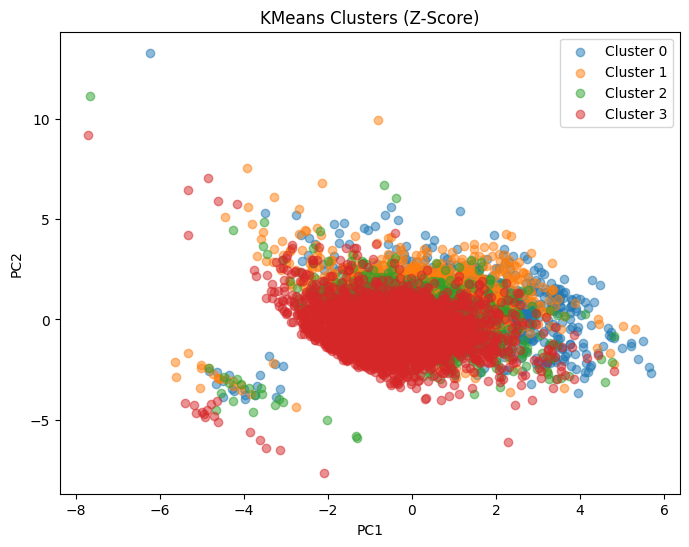

In [86]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_zscore)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[clusters_zscore == cluster, 0],
        X_pca[clusters_zscore == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (Z-Score)')
plt.legend()
plt.show()


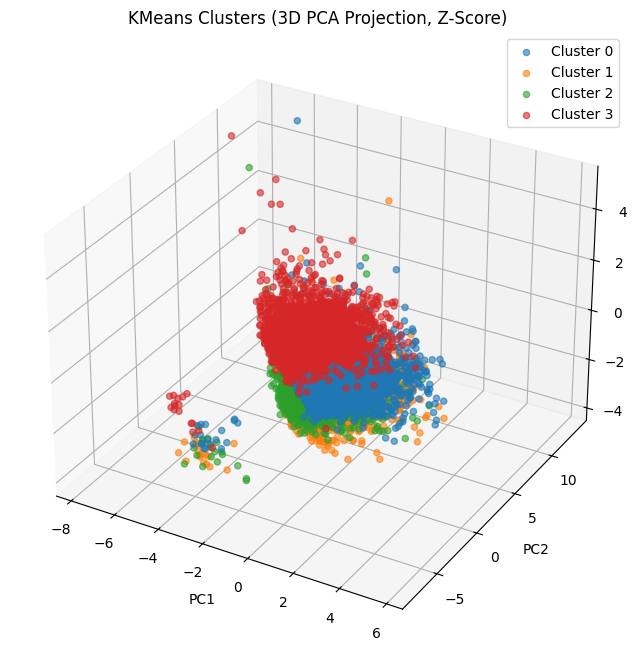

In [87]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_zscore)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[clusters_zscore == cluster, 0],
        X_pca_3d[clusters_zscore == cluster, 1],
        X_pca_3d[clusters_zscore == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, Z-Score)')
ax.legend()

plt.show()


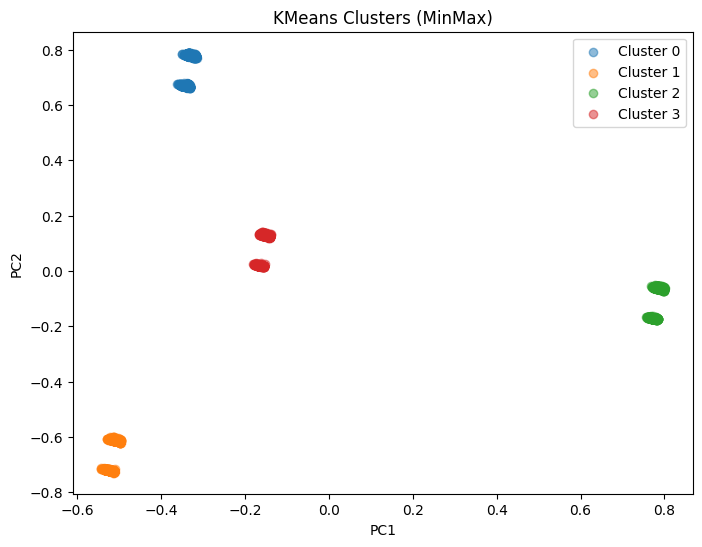

In [88]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_minmax)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[clusters_minmax == cluster, 0],
        X_pca[clusters_minmax == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (MinMax)')
plt.legend()
plt.show()


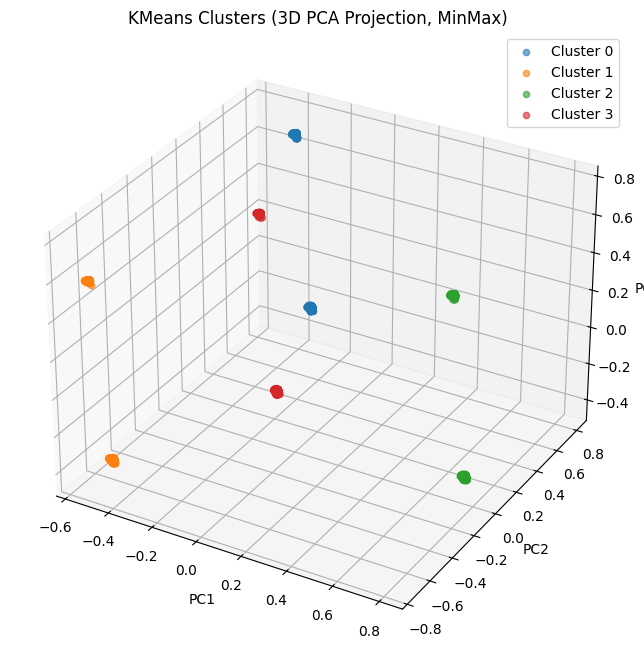

In [89]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots even if unused
import numpy as np

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_minmax)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[clusters_minmax == cluster, 0],
        X_pca_3d[clusters_minmax == cluster, 1],
        X_pca_3d[clusters_minmax == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, MinMax)')
ax.legend()

plt.show()


### Evaluation

In [90]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_zscore, clusters_zscore)
print(f'Silhouette Score (Zscore): {score:.3f}')


Silhouette Score (Zscore): 0.328


In [91]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_minmax, clusters_minmax)
print(f'Silhouette Score (MinMax): {score:.3f}')


Silhouette Score (MinMax): 0.606
